In [1]:
!pip install sktime

In [2]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.datasets import load_airline

y = load_airline()

forecaster = NaiveForecaster(strategy="mean", sp=12)
forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3])

print(y_pred)
print(type(forecaster))
print(forecaster.get_tags())

1961-01    241.750000
1961-02    235.000000
1961-03    270.166667
Freq: M, Name: Number of airline passengers, dtype: float64
<class 'sktime.forecasting.naive._naive.NaiveForecaster'>
{'python_version': None, 'python_dependencies': None, 'env_marker': None, 'sktime_version': '0.40.1', 'property:randomness': 'deterministic', 'capability:random_state': False, 'tests:core': True, 'tests:vm': False, 'tests:libs': None, 'tests:skip_all': False, 'tests:skip_by_name': None, 'authors': ['mloning', 'piyush1729', 'sri1419', 'Flix6x', 'aiwalter', 'IlyasMoutawwakil', 'fkiraly', 'bethrice44'], 'maintainers': 'sktime developers', 'object_type': 'forecaster', 'scitype:y': 'univariate', 'capability:exogenous': False, 'capability:insample': True, 'capability:pred_int': True, 'capability:pred_int:insample': True, 'capability:missing_values': True, 'y_inner_mtype': 'pd.Series', 'X_inner_mtype': 'pd.DataFrame', 'requires-fh-in-fit': False, 'X-y-must-have-same-index': True, 'enforce_index_type': None, 'fit

In [3]:
from sktime.forecasting.base import BaseForecaster
help(BaseForecaster._fit)
help(BaseForecaster._predict)

Help on function _fit in module sktime.forecasting.base._base:

_fit(self, y, X, fh)
    Fit forecaster to training data.

    private _fit containing the core logic, called from fit

    Writes to self:
        Sets fitted model attributes ending in "_".

    Parameters
    ----------
    y : guaranteed to be of a type in self.get_tag("y_inner_mtype")
        Time series to which to fit the forecaster.
        if self.get_tag("scitype:y")=="univariate":
            guaranteed to have a single column/variable
        if self.get_tag("scitype:y")=="multivariate":
            guaranteed to have 2 or more columns
        if self.get_tag("scitype:y")=="both": no restrictions apply
    fh : guaranteed to be ForecastingHorizon or None, optional (default=None)
        The forecasting horizon with the steps ahead to to predict.
        Required (non-optional) here if self.get_tag("requires-fh-in-fit")==True
        Otherwise, if not passed in _fit, guaranteed to be passed in _predict
    X : o

In [4]:
!pip install pmdarima

In [5]:
!pip install pmdarima --quiet

In [6]:

from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.compose import TransformedTargetForecaster

pipeline = TransformedTargetForecaster([
    ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
    ("forecast", AutoARIMA())
])

pipeline.fit(y)
y_pred = pipeline.predict(fh=[1, 2, 3])
print(y_pred)
print(type(pipeline))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/mo

1961-01    440.506005
1961-02    455.355347
1961-03    482.382779
Freq: M, Name: Number of airline passengers, dtype: float64
<class 'sktime.forecasting.compose._pipeline.TransformedTargetForecaster'>


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
from sktime.forecasting.base import BaseForecaster
import pandas as pd

class LLMPipelineForecaster(BaseForecaster):
    """
    A forecaster that uses an LLM to compose and fit an sktime pipeline
    based on a natural language prompt and data characteristics.
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
    }

    def __init__(self, prompt, llm_provider="openai", model="gpt-4o"):
        self.prompt = prompt
        self.llm_provider = llm_provider
        self.model = model
        self.pipeline_ = None
        self.reasoning_ = None
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        # Step 1: analyze data characteristics
        data_summary = self._analyze_series(y)

        # Step 2: ask LLM to compose a pipeline
        pipeline_config = self._ask_llm(data_summary)

        # Step 3: build and fit the sktime pipeline
        self.pipeline_ = self._build_pipeline(pipeline_config)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _analyze_series(self, y):
        """Extract basic statistics from the time series."""
        summary = {
            "length": len(y),
            "mean": round(y.mean(), 2),
            "std": round(y.std(), 2),
            "min": round(y.min(), 2),
            "max": round(y.max(), 2),
            "freq": str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        }
        return summary

    def _ask_llm(self, data_summary):
        """Placeholder - will connect to LLM next step."""
        print(f"Data summary sent to LLM: {data_summary}")
        print(f"User prompt: {self.prompt}")
        # For now return a hardcoded config
        return {"detrend": True, "model": "naive"}

    def _build_pipeline(self, config):
        """Build sktime pipeline from LLM config."""
        from sktime.forecasting.naive import NaiveForecaster
        # For now always return a naive forecaster
        return NaiveForecaster(strategy="mean")


# TEST IT
forecaster = LLMPipelineForecaster(
    prompt="Forecast monthly airline passengers for next 3 months"
)
forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3])
print("\nPredictions:")
print(y_pred)
print("\nForecaster type:", type(forecaster))

Data summary sent to LLM: {'length': 144, 'mean': np.float64(280.3), 'std': 119.97, 'min': 104.0, 'max': 622.0, 'freq': 'M'}
User prompt: Forecast monthly airline passengers for next 3 months

Predictions:
1961-01    280.298611
1961-02    280.298611
1961-03    280.298611
Freq: M, Name: Number of airline passengers, dtype: float64

Forecaster type: <class '__main__.LLMPipelineForecaster'>


In [8]:
!pip install groq --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.5 MB/s eta 0:00:00


In [41]:
from groq import Groq

client = Groq(api_key=GROQ_KEY)

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(response.choices[0].message.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [10]:
import pandas as pd
import json
from groq import Groq
from sktime.forecasting.base import BaseForecaster

class LLMPipelineForecaster(BaseForecaster):
    """
    A forecaster that uses an LLM to compose and fit an sktime pipeline
    based on a natural language prompt and data characteristics.
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
    }

    def __init__(self, prompt, api_key, model="llama-3.3-70b-versatile"):
        self.prompt = prompt
        self.api_key = api_key
        self.model = model
        self.pipeline_ = None
        self.reasoning_ = None
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        # Step 1: analyze data
        data_summary = self._analyze_series(y)

        # Step 2: ask LLM to compose pipeline
        pipeline_config, reasoning = self._ask_llm(data_summary)
        self.reasoning_ = reasoning

        # Step 3: build and fit pipeline
        self.pipeline_ = self._build_pipeline(pipeline_config)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _analyze_series(self, y):
        """Extract basic statistics from the time series."""
        # detect simple seasonality
        freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
        sp = sp_map.get(freq, 1)

        return {
            "length": len(y),
            "mean": round(float(y.mean()), 2),
            "std": round(float(y.std()), 2),
            "min": round(float(y.min()), 2),
            "max": round(float(y.max()), 2),
            "freq": freq,
            "seasonal_period": sp,
            "trend_slope": round(float(y.iloc[-1] - y.iloc[0]), 2)
        }

    def _ask_llm(self, data_summary):
        """Ask LLM to choose pipeline components based on data and prompt."""

        system_prompt = """You are an expert time series forecasting assistant.
Given a dataset summary and a user prompt, you must choose the best sktime pipeline.

You must respond with ONLY a valid JSON object, no explanation, no markdown, just JSON.
The JSON must have exactly these fields:
{
    "detrend": true or false,
    "deseasonalize": true or false,
    "model": one of ["naive", "arima", "ets"],
    "reasoning": "one sentence explanation of your choice"
}

Rules:
- If trend_slope is large (>50 or <-50), set detrend to true
- If seasonal_period > 1, set deseasonalize to true
- If series is short (<50 points), use "naive"
- If series has strong trend or seasonality, use "ets"
- Otherwise use "arima"
"""

        user_message = f"""
User prompt: {self.prompt}
Data summary: {json.dumps(data_summary)}

Respond with JSON only.
"""

        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=0
        )

        raw = response.choices[0].message.content.strip()
        print(f"\nLLM raw response:\n{raw}\n")

        config = json.loads(raw)
        reasoning = config.pop("reasoning", "No reasoning provided")
        return config, reasoning

    def _build_pipeline(self, config):
        """Build sktime pipeline from LLM config."""
        from sktime.forecasting.naive import NaiveForecaster
        from sktime.forecasting.exp_smoothing import ExponentialSmoothing
        from sktime.forecasting.arima import AutoARIMA
        from sktime.transformations.series.detrend import Detrender, Deseasonalizer
        from sktime.forecasting.trend import PolynomialTrendForecaster
        from sktime.forecasting.compose import TransformedTargetForecaster

        # choose base model
        model_map = {
            "naive": NaiveForecaster(strategy="last"),
            "arima": AutoARIMA(sp=1),
            "ets": ExponentialSmoothing(trend="add", seasonal="add", sp=12)
        }
        model = model_map.get(config.get("model", "naive"))

        # build transformation steps
        steps = []
        if config.get("detrend"):
            steps.append(("detrend", Detrender(
                forecaster=PolynomialTrendForecaster(degree=1)
            )))
        if config.get("deseasonalize"):
            steps.append(("deseasonalize", Deseasonalizer(sp=12)))

        if steps:
            steps.append(("forecast", model))
            return TransformedTargetForecaster(steps)
        else:
            return model

In [ ]:
from google.colab import userdata
# This opens a secure input box - paste your key there
import getpass
GROQ_KEY = getpass.getpass("Paste your Groq API key: ")

In [12]:
from sktime.datasets import load_airline

y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast monthly airline passengers for next 3 months",
    api_key=GROQ_KEY  # uses the key you just entered securely
)

forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3])

print("Pipeline chosen by LLM:")
print(type(forecaster.pipeline_))
print("\nLLM Reasoning:")
print(forecaster.reasoning_)
print("\nPredictions:")
print(y_pred)


LLM raw response:
{
    "detrend": true,
    "deseasonalize": true,
    "model": "ets",
    "reasoning": "The series has a large trend slope and strong seasonality, making ETS a suitable model."
}

Pipeline chosen by LLM:
<class 'sktime.forecasting.compose._pipeline.TransformedTargetForecaster'>

LLM Reasoning:
The series has a large trend slope and strong seasonality, making ETS a suitable model.

Predictions:
1961-01    451.577704
1961-02    427.258102
1961-03    464.698828
Freq: M, Name: Number of airline passengers, dtype: float64


In [13]:
!pip install statsmodels --quiet

In [14]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, acf

def analyze_series_advanced(y):
    """
    Analyze time series characteristics using statistical tests.
    Returns a rich summary for the LLM to reason about.
    """
    freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
    sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
    sp = sp_map.get(freq, 1)

    # stationarity test
    adf_result = adfuller(y.dropna())
    is_stationary = adf_result[1] < 0.05  # p-value < 0.05 means stationary

    # trend detection
    x = np.arange(len(y))
    trend_coef = np.polyfit(x, y.values, 1)[0]
    has_trend = abs(trend_coef) > (y.std() * 0.01)

    # seasonality detection via ACF
    if sp > 1 and len(y) > sp * 2:
        acf_vals = acf(y.dropna(), nlags=sp, fft=True)
        seasonal_strength = abs(acf_vals[sp])
        has_seasonality = seasonal_strength > 0.3
    else:
        seasonal_strength = 0
        has_seasonality = False

    return {
        "length": len(y),
        "mean": round(float(y.mean()), 2),
        "std": round(float(y.std()), 2),
        "min": round(float(y.min()), 2),
        "max": round(float(y.max()), 2),
        "freq": freq,
        "seasonal_period": sp,
        "is_stationary": bool(is_stationary),
        "has_trend": bool(has_trend),
        "trend_slope": round(float(trend_coef), 4),
        "has_seasonality": bool(has_seasonality),
        "seasonal_strength": round(float(seasonal_strength), 4)
    }

# test it on airline data
summary = analyze_series_advanced(y)
for k, v in summary.items():
    print(f"{k}: {v}")

length: 144
mean: 280.3
std: 119.97
min: 104.0
max: 622.0
freq: M
seasonal_period: 12
is_stationary: False
has_trend: True
trend_slope: 2.6572
has_seasonality: True
seasonal_strength: 0.7604


In [15]:
import pandas as pd
import json
import numpy as np
from groq import Groq
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.stattools import adfuller, acf

class LLMPipelineForecaster(BaseForecaster):
    """
    An sktime-compatible forecaster that uses an LLM to compose
    a full sktime pipeline based on a natural language prompt
    and statistical analysis of the input data.

    Parameters
    ----------
    prompt : str
        Natural language description of the forecasting task.
    api_key : str
        Groq API key.
    model : str
        LLM model to use.

    Attributes
    ----------
    pipeline_ : sktime forecaster
        The fitted pipeline chosen by the LLM.
    reasoning_ : str
        The LLM's explanation of its pipeline choice.
    data_summary_ : dict
        Statistical summary of the training data.
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
    }

    def __init__(self, prompt, api_key, model="llama-3.3-70b-versatile"):
        self.prompt = prompt
        self.api_key = api_key
        self.model = model
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        # Step 1: analyze data with statistical tests
        self.data_summary_ = self._analyze_series(y)

        # Step 2: ask LLM to compose pipeline
        pipeline_config, self.reasoning_ = self._ask_llm(self.data_summary_)
        self.pipeline_config_ = pipeline_config

        # Step 3: build and fit the pipeline
        self.pipeline_ = self._build_pipeline(pipeline_config)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _analyze_series(self, y):
        """Analyze time series using statistical tests."""
        freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
        sp = sp_map.get(freq, 1)

        # stationarity
        adf_result = adfuller(y.dropna())
        is_stationary = bool(adf_result[1] < 0.05)

        # trend
        x = np.arange(len(y))
        trend_coef = float(np.polyfit(x, y.values, 1)[0])
        has_trend = abs(trend_coef) > (y.std() * 0.01)

        # seasonality
        if sp > 1 and len(y) > sp * 2:
            acf_vals = acf(y.dropna(), nlags=sp, fft=True)
            seasonal_strength = float(abs(acf_vals[sp]))
            has_seasonality = seasonal_strength > 0.3
        else:
            seasonal_strength = 0.0
            has_seasonality = False

        return {
            "length": len(y),
            "mean": round(float(y.mean()), 2),
            "std": round(float(y.std()), 2),
            "min": round(float(y.min()), 2),
            "max": round(float(y.max()), 2),
            "freq": freq,
            "seasonal_period": sp,
            "is_stationary": is_stationary,
            "has_trend": bool(has_trend),
            "trend_slope": round(trend_coef, 4),
            "has_seasonality": has_seasonality,
            "seasonal_strength": round(seasonal_strength, 4)
        }

    def _ask_llm(self, data_summary):
        """Ask LLM to choose pipeline based on data statistics and prompt."""

        system_prompt = """You are an expert time series forecasting assistant.
Given a statistical summary of a time series and a user prompt, choose the best sktime pipeline.

Respond with ONLY a valid JSON object. No explanation outside the JSON. No markdown.
The JSON must have exactly these fields:
{
    "detrend": true or false,
    "deseasonalize": true or false,
    "model": one of ["naive", "arima", "ets"],
    "reasoning": "one sentence explanation"
}

Decision rules:
- If has_trend is true, set detrend to true
- If has_seasonality is true, set deseasonalize to true
- If length < 50, use "naive"
- If is_stationary is false and has_seasonality is true, use "ets"
- If is_stationary is true, use "arima"
- Otherwise use "arima"
"""

        user_message = f"""
User prompt: {self.prompt}
Data statistics: {json.dumps(data_summary, indent=2)}

Respond with JSON only.
"""

        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=0
        )

        raw = response.choices[0].message.content.strip()
        config = json.loads(raw)
        reasoning = config.pop("reasoning", "No reasoning provided")
        return config, reasoning

    def _build_pipeline(self, config):
        """Build sktime pipeline from LLM config dict."""
        from sktime.forecasting.naive import NaiveForecaster
        from sktime.forecasting.exp_smoothing import ExponentialSmoothing
        from sktime.forecasting.arima import AutoARIMA
        from sktime.transformations.series.detrend import (
            Detrender, Deseasonalizer
        )
        from sktime.forecasting.trend import PolynomialTrendForecaster
        from sktime.forecasting.compose import TransformedTargetForecaster

        sp = self.data_summary_.get("seasonal_period", 1)

        model_map = {
            "naive": NaiveForecaster(strategy="last"),
            "arima": AutoARIMA(sp=sp),
            "ets": ExponentialSmoothing(
                trend="add", seasonal="add", sp=sp
            )
        }
        model = model_map.get(config.get("model", "naive"))

        steps = []
        if config.get("detrend"):
            steps.append((
                "detrend",
                Detrender(forecaster=PolynomialTrendForecaster(degree=1))
            ))
        if config.get("deseasonalize"):
            steps.append(("deseasonalize", Deseasonalizer(sp=sp)))

        if steps:
            steps.append(("forecast", model))
            return TransformedTargetForecaster(steps)
        else:
            return model

    def get_pipeline_description(self):
        """Return human-readable description of the chosen pipeline."""
        if not hasattr(self, 'reasoning_'):
            return "Forecaster not fitted yet."
        config = self.pipeline_config_
        steps = []
        if config.get("detrend"):
            steps.append("detrending")
        if config.get("deseasonalize"):
            steps.append("deseasonalization")
        steps.append(f"{config.get('model').upper()} model")
        pipeline_str = " → ".join(steps)
        return (
            f"Pipeline: {pipeline_str}\n"
            f"Reasoning: {self.reasoning_}\n"
            f"Data: {self.data_summary_['length']} points, "
            f"freq={self.data_summary_['freq']}, "
            f"trend={self.data_summary_['has_trend']}, "
            f"seasonality={self.data_summary_['has_seasonality']}"
        )

In [16]:
from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast monthly airline passengers for next 3 months",
    api_key=GROQ_KEY
)

forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3])

print(forecaster.get_pipeline_description())
print("\nPredictions:")
print(y_pred)

Pipeline: detrending → deseasonalization → ETS model
Reasoning: The time series has seasonality and is not stationary, so ets is the most suitable model.
Data: 144 points, freq=M, trend=True, seasonality=True

Predictions:
1961-01    451.577704
1961-02    427.258102
1961-03    464.698828
Freq: M, Name: Number of airline passengers, dtype: float64


In [38]:
import pandas as pd
import json
import numpy as np
from groq import Groq
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.stattools import adfuller, acf

class LLMPipelineForecaster(BaseForecaster):
    """
    An sktime-compatible forecaster that uses an LLM to compose
    a full sktime pipeline based on a natural language prompt
    and statistical analysis of the input data.

    Uses an iterative self-correction loop — if the chosen pipeline
    performs poorly, the LLM is asked to revise its choice.

    Parameters
    ----------
    prompt : str
        Natural language description of the forecasting task.
    api_key : str
        Groq API key.
    model : str
        LLM model to use.
    max_iterations : int
        Maximum number of correction attempts.
    mae_threshold : float
        If MAE is below this fraction of data std, accept pipeline.
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
        "capability:pred_int": True,
    }

    def __init__(
        self,
        prompt,
        api_key,
        model="llama-3.3-70b-versatile",
        max_iterations=3,
        mae_threshold=0.2
    ):
        self.prompt = prompt
        self.api_key = api_key
        self.model = model
        self.max_iterations = max_iterations
        self.mae_threshold = mae_threshold
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        # Step 1: analyze data
        self.data_summary_ = self._analyze_series(y)
        self._y = y # Store y for potential use in predict_interval fallback

        # Step 2: split for internal evaluation
        split = int(len(y) * 0.8)
        y_train = y.iloc[:split]
        y_val = y.iloc[split:]
        val_fh = list(range(1, len(y_val) + 1))

        best_pipeline = None
        best_mae = float("inf")
        self.iteration_log_ = []
        previous_attempts = []

        # Step 3: iterative loop
        for i in range(self.max_iterations):
            print(f"\n--- Iteration {i+1} ---")

            # ask LLM
            config, reasoning = self._ask_llm(
                self.data_summary_,
                previous_attempts=previous_attempts
            )
            print(f"LLM chose: {config}")
            print(f"Reasoning: {reasoning}")

            # build and evaluate pipeline
            try:
                pipeline = self._build_pipeline(config)
                pipeline.fit(y_train)
                y_pred_val = pipeline.predict(fh=val_fh)

                # align indices for MAE calculation
                y_pred_val.index = y_val.index
                mae = float(np.mean(np.abs(y_val.values - y_pred_val.values)))
                mae_relative = mae / self.data_summary_["std"]
                print(f"MAE: {mae:.2f} (relative: {mae_relative:.3f})")

            except Exception as e:
                print(f"Pipeline failed: {e}")
                mae = float("inf")
                mae_relative = float("inf")

            # log this attempt
            attempt = {
                "iteration": i + 1,
                "config": config,
                "reasoning": reasoning,
                "mae": round(mae, 2),
                "mae_relative": round(mae_relative, 3)
            }
            self.iteration_log_.append(attempt)
            previous_attempts.append(attempt)

            # track best
            if mae < best_mae:
                best_mae = mae
                best_pipeline = pipeline
                self.reasoning_ = reasoning
                self.pipeline_config_ = config

            # stop early if good enough
            if mae_relative < self.mae_threshold:
                print(f"Accepted pipeline at iteration {i+1}")
                break

        # Step 4: refit best pipeline on full data
        print(f"\nBest pipeline MAE: {best_mae:.2f}")
        print("Refitting best pipeline on full data...")
        self.pipeline_ = self._build_pipeline(self.pipeline_config_)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _analyze_series(self, y):
        """Analyze time series using statistical tests."""
        freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
        sp = sp_map.get(freq, 1)

        adf_result = adfuller(y.dropna())
        is_stationary = bool(adf_result[1] < 0.05)

        x = np.arange(len(y))
        trend_coef = float(np.polyfit(x, y.values, 1)[0])
        has_trend = abs(trend_coef) > (y.std() * 0.01)

        if sp > 1 and len(y) > sp * 2:
            acf_vals = acf(y.dropna(), nlags=sp, fft=True)
            seasonal_strength = float(abs(acf_vals[sp]))
            has_seasonality = seasonal_strength > 0.3
        else:
            seasonal_strength = 0.0
            has_seasonality = False

        return {
            "length": len(y),
            "mean": round(float(y.mean()), 2),
            "std": round(float(y.std()), 2),
            "min": round(float(y.min()), 2),
            "max": round(float(y.max()), 2),
            "freq": freq,
            "seasonal_period": sp,
            "is_stationary": is_stationary,
            "has_trend": bool(has_trend),
            "trend_slope": round(trend_coef, 4),
            "has_seasonality": has_seasonality,
            "seasonal_strength": round(seasonal_strength, 4)
        }

    def _ask_llm(self, data_summary, previous_attempts=None):
        """Ask LLM to choose pipeline, with awareness of previous failures."""

        system_prompt = """You are an expert time series forecasting assistant.
Given a statistical summary of a time series and a user prompt, choose the best sktime pipeline.

Respond with ONLY a valid JSON object. No markdown. No explanation outside JSON.
The JSON must have exactly these fields:
{
    "detrend": true or false,
    "deseasonalize": true or false,
    "model": one of ["naive", "arima", "ets"],
    "reasoning": "one sentence explanation"
}

Decision rules:
- If has_trend is true, set detrend to true
- If has_seasonality is true, set deseasonalize to true
- If length < 50, use "naive"
- If is_stationary is false and has_seasonality is true, use "ets"
- If is_stationary is true, use "arima"
- Otherwise use "arima"
- If previous attempts failed, try a DIFFERENT model
"""

        # build message with previous attempts context
        attempts_str = ""
        if previous_attempts:
            attempts_str = "\nPrevious attempts and their MAE:\n"
            for a in previous_attempts:
                attempts_str += (
                    f"- Iteration {a['iteration']}: "
                    f"model={a['config']['model']}, "
                    f"MAE={a['mae']}, "
                    f"relative_MAE={a['mae_relative']}\n"
                )
            attempts_str += "\nChoose a DIFFERENT configuration to improve on these."

        user_message = f"""
User prompt: {self.prompt}
Data statistics: {json.dumps(data_summary, indent=2)}
{attempts_str}
Respond with JSON only.
"""

        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=0.2
        )

        raw = response.choices[0].message.content.strip()
        config = json.loads(raw)
        reasoning = config.pop("reasoning", "No reasoning provided")
        return config, reasoning

    def _build_pipeline(self, config):
        """Build sktime pipeline from LLM config dict."""
        from sktime.forecasting.naive import NaiveForecaster
        from sktime.forecasting.exp_smoothing import ExponentialSmoothing
        from sktime.forecasting.arima import AutoARIMA
        from sktime.transformations.series.detrend import (
            Detrender, Deseasonalizer
        )
        from sktime.forecasting.trend import PolynomialTrendForecaster
        from sktime.forecasting.compose import TransformedTargetForecaster

        sp = self.data_summary_.get("seasonal_period", 1)

        model_map = {
            "naive": NaiveForecaster(strategy="last"),
            "arima": AutoARIMA(sp=sp),
            "ets": ExponentialSmoothing(
                trend="add", seasonal="add", sp=sp
            )
        }
        model = model_map.get(config.get("model", "naive"))

        steps = []
        if config.get("detrend"):
            steps.append((
                "detrend",
                Detrender(forecaster=PolynomialTrendForecaster(degree=1))
            ))
        if config.get("deseasonalize"):
            steps.append(("deseasonalize", Deseasonalizer(sp=sp)))

        if steps:
            steps.append(("forecast", model))
            return TransformedTargetForecaster(steps)
        else:
            return model

    def get_pipeline_description(self):
        """Return human-readable description of the chosen pipeline."""
        if not hasattr(self, 'reasoning_'):
            return "Forecaster not fitted yet."
        config = self.pipeline_config_
        steps = []
        if config.get("detrend"):
            steps.append("detrending")
        if config.get("deseasonalize"):
            steps.append("deseasonalization")
        steps.append(f"{config.get('model').upper()} model")
        pipeline_str = " \u2192 ".join(steps)
        return (
            f"Pipeline: {pipeline_str}\n"
            f"Reasoning: {self.reasoning_}\n"
            f"Data: {self.data_summary_['length']} points, "
            f"freq={self.data_summary_['freq']}, "
            f"trend={self.data_summary_['has_trend']}, "
            f"seasonality={self.data_summary_['has_seasonality']}"
        )

    def get_iteration_log(self):
        """Return summary of all iterations."""
        if not hasattr(self, 'iteration_log_'):
            return "Forecaster not fitted yet."
        print(f"{'Iter':<6}{'Model':<8}"
              f"{'Detrend':<10}{'Deseas':<10}"
              f"{'MAE':<12}{'Relative MAE'}")
        print("-" * 55)
        for log in self.iteration_log_:
            print(
                f"{log['iteration']:<6}"
                f"{log['config']['model']:<8}"
                f"{str(log['config']['detrend']):<10}"
                f"{str(log['config']['deseasonalize']):<10}"
                f"{log['mae']:<12}"
                f"{log['mae_relative']}"
            )
    def _predict_interval(self, fh, X=None, coverage=0.9):
        """
        Return prediction intervals.

        If the fitted model supports intervals natively, uses those.
        If not (e.g. ETS), falls back to NaiveForecaster intervals
        as a conservative estimate.

        Parameters
        ----------
        fh : ForecastingHorizon or list of int
        coverage : float
            Nominal coverage of the intervals.

        Returns
        -------
        pd.DataFrame with columns (lower, upper) at given coverage
        """
        # check if fitted pipeline supports intervals
        model_name = self.pipeline_config_.get("model", "naive")

        if model_name in ["naive", "arima"]:
            # supported natively
            return self.pipeline_.predict_interval(fh=fh, coverage=coverage)
        else:
            # ETS fallback — use NaiveForecaster for interval shape
            print(
                f"Note: {model_name.upper()} does not support prediction "
                "intervals natively. Using NaiveForecaster as fallback."
            )
            from sktime.forecasting.naive import NaiveForecaster
            naive = NaiveForecaster(strategy="last")
            # fit on original data, not just training split
            naive.fit(self._y)
            return naive.predict_interval(fh=fh, coverage=coverage)

    def get_confidence_assessment(self):
        """
        Return LLM-generated confidence assessment of the forecast.

        Based on data quality, series length, MAE, and stationarity.

        Returns
        -------
        dict with keys: confidence, reasons, warning
        """
        if not hasattr(self, 'iteration_log_'):
            return "Forecaster not fitted yet."

        summary = self.data_summary_
        valid_maes = [
            i["mae"] for i in self.iteration_log_
            if isinstance(i["mae"], (int, float))
        ]
        best_mae_relative = min(
            i["mae_relative"] for i in self.iteration_log_
            if isinstance(i["mae_relative"], (int, float))
        )

        # build confidence assessment prompt
        assessment_prompt = f"""
You are a time series forecasting expert.
Given this information about a fitted forecasting model, assess confidence.

Data summary:
- Length: {summary['length']} points
- Is stationary: {summary['is_stationary']}
- Has trend: {summary['has_trend']}
- Has seasonality: {summary['has_seasonality']}
- Seasonal strength: {summary['seasonal_strength']}

Model performance:
- Best relative MAE: {best_mae_relative} (lower is better, <0.1 excellent, 0.1-0.2 good, 0.2-0.3 fair, >0.3 poor)
- Models tried: {[i['config']['model'] for i in self.iteration_log_]}
- Any failures: {any(i.get('failed') for i in self.iteration_log_)}

Respond with ONLY valid JSON, no markdown:
{{
    "confidence": "high", "medium", or "low",
    "reasons": ["reason 1", "reason 2"],
    "warning": null or "one sentence warning if confidence is low or medium"
}}
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "user", "content": assessment_prompt}
            ],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        return json.loads(raw)

from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3, 4, 5, 6])

# test prediction intervals
print("=== PREDICTION INTERVALS ===")
intervals = forecaster.predict_interval(fh=[1, 2, 3, 4, 5, 6], coverage=0.9)
print(intervals)

# test confidence assessment
print("\n=== CONFIDENCE ASSESSMENT ===")
confidence = forecaster.get_confidence_assessment()
for k, v in confidence.items():
    print(f"{k}: {v}")


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Switching to arima model as previous attempt with ets model had a relatively high MAE and the data has both trend and seasonality.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Trying a naive model as a different approach after previous attempts with ets and arima models.
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 25.68
Refitting best pipeline on full data...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== PREDICTION INTERVALS ===
        Number of airline passengers            
                                 0.9            
                               lower       upper
1961-01                   425.922772  462.581782
1961-02                   399.842715  445.961225
1961-03                   428.093245  478.918078
1961-04                   460.033114  513.409163
1961-05                   469.787273  524.595099
1961-06                   528.482441  584.107524

=== CONFIDENCE ASSESSMENT ===
confidence: medium
reasons: ['The model has a fair relative MAE of 0.214, indicating some degree of accuracy but room for improvement', 'The data has strong seasonality, which can be challenging to model accurately']


In [18]:
from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast monthly airline passengers for next 3 months",
    api_key=GROQ_KEY,
    max_iterations=3
)

forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3])

print("\n=== ITERATION LOG ===")
forecaster.get_iteration_log()

print("\n=== FINAL PIPELINE ===")
print(forecaster.get_pipeline_description())

print("\n=== PREDICTIONS ===")
print(y_pred)


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ETS is a suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Switching to arima model as previous attempt with ets model had a relatively high MAE and the time series has both trend and seasonality.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Switching to naive model as previous attempts with ets and arima did not yield satisfactory results.
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 25.68
Refitting best pipeline on full data...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== ITERATION LOG ===
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     ets     True      True      31.79       0.265
2     arima   True      True      25.68       0.214
3     naive   True      True      50.4        0.42

=== FINAL PIPELINE ===
Pipeline: detrending → deseasonalization → ARIMA model
Reasoning: Switching to arima model as previous attempt with ets model had a relatively high MAE and the time series has both trend and seasonality.
Data: 144 points, freq=M, trend=True, seasonality=True

=== PREDICTIONS ===
1961-01    444.252277
1961-02    422.901970
1961-03    453.505661
Freq: M, Name: Number of airline passengers, dtype: float64


In [19]:
from sktime.datasets import load_longley
import pandas as pd

# load a different dataset - employment data, quarterly
y2, X2 = load_longley()
y2 = y2.astype(float)
print(y2.head())
print(f"Length: {len(y2)}, Freq: {y2.index.freqstr}")

Period
1947    60323.0
1948    61122.0
1949    60171.0
1950    61187.0
1951    63221.0
Freq: Y-DEC, Name: TOTEMP, dtype: float64
Length: 16, Freq: Y-DEC


In [20]:
forecaster2 = LLMPipelineForecaster(
    prompt="Forecast total employment in the US for the next 2 years",
    api_key=GROQ_KEY,
    max_iterations=3
)

forecaster2.fit(y2)
y_pred2 = forecaster2.predict(fh=[1, 2])

print("\n=== ITERATION LOG ===")
forecaster2.get_iteration_log()

print("\n=== FINAL PIPELINE ===")
print(forecaster2.get_pipeline_description())

print("\n=== PREDICTIONS ===")
print(y_pred2)


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'naive'}
Reasoning: The time series has a trend but no seasonality and a short length, so a naive model is chosen.
MAE: 1155.21 (relative: 0.329)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'arima'}
Reasoning: Since the time series has a trend and is not stationary, and previous attempt with naive model failed, trying arima model with detrending.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 370.84 (relative: 0.106)
Accepted pipeline at iteration 2

Best pipeline MAE: 370.84
Refitting best pipeline on full data...

=== ITERATION LOG ===
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     naive   True      False     1155.21     0.329
2     arima   True      False     370.84      0.106

=== FINAL PIPELINE ===
Pipeline: detrending → ARIMA model
Reasoning: Since the time series has a trend and is not stationary, and previous attempt with naive model failed, trying arima model with detrending.
Data: 16 points, freq=Y-DEC, trend=True, seasonality=False

=== PREDICTIONS ===
1963    71407.350000
1964    72123.861765
Freq: Y-DEC, Name: TOTEMP, dtype: float64


In [21]:
import pandas as pd
import numpy as np

# create a sample CSV that mimics what a real user would have
dates = pd.date_range(start="2020-01-01", periods=36, freq="ME")
values = (
    100
    + np.arange(36) * 2          # trend
    + 10 * np.sin(np.arange(36) * 2 * np.pi / 12)  # seasonality
    + np.random.normal(0, 3, 36)  # noise
)

df = pd.DataFrame({"date": dates, "sales": values})
df.to_csv("sample_sales.csv", index=False)
print(df.head(10))
print(f"\nShape: {df.shape}")

        date       sales
0 2020-01-31   98.499410
1 2020-02-29   98.731609
2 2020-03-31  109.328596
3 2020-04-30  115.278966
4 2020-05-31  112.310992
5 2020-06-30  114.405610
6 2020-07-31  116.011019
7 2020-08-31  107.944783
8 2020-09-30  106.985186
9 2020-10-31  113.903040

Shape: (36, 2)


In [22]:
def load_time_series(data, date_col=None, value_col=None):
    """
    Load time series data from multiple input formats into sktime-compatible pd.Series.

    Parameters
    ----------
    data : str, pd.DataFrame, or pd.Series
        - str: path to CSV file
        - pd.DataFrame: must have a date column and value column
        - pd.Series: used directly if already sktime-compatible
    date_col : str, optional
        Name of date column. If None, auto-detected.
    value_col : str, optional
        Name of value column. If None, auto-detected.

    Returns
    -------
    y : pd.Series with PeriodIndex, ready for sktime
    """
    # --- Case 1: already a pd.Series ---
    if isinstance(data, pd.Series):
        if isinstance(data.index, pd.PeriodIndex):
            return data
        # try to convert index to PeriodIndex
        try:
            data.index = pd.PeriodIndex(data.index, freq="M")
            return data
        except Exception:
            return data

    # --- Case 2: CSV file path ---
    if isinstance(data, str):
        print(f"Loading CSV from: {data}")
        data = pd.read_csv(data)

    # --- Case 3: pd.DataFrame ---
    if isinstance(data, pd.DataFrame):
        # auto-detect date column
        if date_col is None:
            for col in data.columns:
                if any(kw in col.lower() for kw in
                       ["date", "time", "period", "month", "year", "day"]):
                    date_col = col
                    break
        # if still not found, take first column
        if date_col is None:
            date_col = data.columns[0]

        # auto-detect value column
        if value_col is None:
            numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
            # exclude the date column if it somehow ended up numeric
            numeric_cols = [c for c in numeric_cols if c != date_col]
            if not numeric_cols:
                raise ValueError("No numeric columns found in DataFrame.")
            value_col = numeric_cols[0]

        print(f"Detected date column: '{date_col}'")
        print(f"Detected value column: '{value_col}'")

        # parse dates
        data[date_col] = pd.to_datetime(data[date_col])
        data = data.sort_values(date_col)

        # infer frequency
        diffs = data[date_col].diff().dropna()
        median_diff = diffs.median().days

        if median_diff <= 1:
            freq = "D"
        elif median_diff <= 8:
            freq = "W"
        elif median_diff <= 32:
            freq = "M"
        elif median_diff <= 93:
            freq = "Q"
        else:
            freq = "Y"

        print(f"Inferred frequency: {freq}")

        # build PeriodIndex series
        period_index = pd.PeriodIndex(
            data[date_col].dt.to_period(freq)
        )
        y = pd.Series(
            data[value_col].values,
            index=period_index,
            name=value_col
        )
        return y

    raise ValueError(
        f"Unsupported data type: {type(data)}. "
        "Pass a CSV path, pd.DataFrame, or pd.Series."
    )


# --- TEST all three input formats ---

# Test 1: CSV path
print("=== Test 1: CSV path ===")
y_csv = load_time_series("sample_sales.csv")
print(y_csv.head())
print(f"Type: {type(y_csv.index)}\n")

# Test 2: DataFrame
print("=== Test 2: DataFrame ===")
df = pd.read_csv("sample_sales.csv")
y_df = load_time_series(df)
print(y_df.head())
print(f"Type: {type(y_df.index)}\n")

# Test 3: existing sktime Series
print("=== Test 3: sktime Series ===")
from sktime.datasets import load_airline
y_sktime = load_airline()
y_direct = load_time_series(y_sktime)
print(y_direct.head())
print(f"Type: {type(y_direct.index)}\n")

=== Test 1: CSV path ===
Loading CSV from: sample_sales.csv
Detected date column: 'date'
Detected value column: 'sales'
Inferred frequency: M
date
2020-01     98.499410
2020-02     98.731609
2020-03    109.328596
2020-04    115.278966
2020-05    112.310992
Freq: M, Name: sales, dtype: float64
Type: <class 'pandas.core.indexes.period.PeriodIndex'>

=== Test 2: DataFrame ===
Detected date column: 'date'
Detected value column: 'sales'
Inferred frequency: M
date
2020-01     98.499410
2020-02     98.731609
2020-03    109.328596
2020-04    115.278966
2020-05    112.310992
Freq: M, Name: sales, dtype: float64
Type: <class 'pandas.core.indexes.period.PeriodIndex'>

=== Test 3: sktime Series ===
Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64
Type: <class 'pandas.core.indexes.period.PeriodIndex'>



In [36]:
import pandas as pd
import json
import numpy as np
from groq import Groq
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.stattools import adfuller, acf

class LLMPipelineForecaster(BaseForecaster):
    """
    An sktime-compatible forecaster that uses an LLM to compose
    a full sktime pipeline based on a natural language prompt
    and statistical analysis of the input data.

    Accepts CSV path, pandas DataFrame, or sktime-compatible Series as input.
    Uses an iterative self-correction loop to improve pipeline selection.

    Parameters
    ----------
    prompt : str
        Natural language description of the forecasting task.
    api_key : str
        Groq API key.
    model : str
        LLM model to use.
    max_iterations : int
        Maximum number of correction attempts.
    mae_threshold : float
        If relative MAE is below this, accept pipeline early.
    date_col : str, optional
        Name of date column in CSV/DataFrame. Auto-detected if None.
    value_col : str, optional
        Name of value column in CSV/DataFrame. Auto-detected if None.

    Attributes
    ----------
    pipeline_ : sktime forecaster
        The fitted pipeline chosen by the LLM.
    reasoning_ : str
        The LLM's explanation of its pipeline choice.
    data_summary_ : dict
        Statistical summary of the training data.
    iteration_log_ : list
        Log of all iterations with MAE scores.

    Examples
    --------
    >>> # from CSV
    >>> forecaster = LLMPipelineForecaster(
    ...     prompt="Forecast sales for next 3 months",
    ...     api_key="your_key"
    ... )
    >>> forecaster.fit("sales.csv")
    >>> y_pred = forecaster.predict(fh=[1, 2, 3])

    >>> # from DataFrame
    >>> forecaster.fit(df)

    >>> # from sktime Series
    >>> from sktime.datasets import load_airline
    >>> forecaster.fit(load_airline())
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
        "capability:pred_int": True,
    }

    def __init__(
        self,
        prompt,
        api_key,
        model="llama-3.3-70b-versatile",
        max_iterations=3,
        mae_threshold=0.2,
        date_col=None,
        value_col=None
    ):
        self.prompt = prompt
        self.api_key = api_key
        self.model = model
        self.max_iterations = max_iterations
        self.mae_threshold = mae_threshold
        self.date_col = date_col
        self.value_col = value_col
        super().__init__()

    def fit(self, y, X=None, fh=None):
        """
        Fit the forecaster.

        Parameters
        ----------
        y : str, pd.DataFrame, or pd.Series
            Time series data. Accepts CSV path, DataFrame, or Series.
        X : ignored
        fh : ForecastingHorizon, optional
        """
        # convert input to sktime-compatible Series
        y = self._load_input(y)
        return super().fit(y, X=X, fh=fh)

    def _load_input(self, data):
        """Convert any input format to sktime-compatible pd.Series."""

        # already a Series
        if isinstance(data, pd.Series):
            if isinstance(data.index, pd.PeriodIndex):
                return data
            try:
                data.index = pd.PeriodIndex(data.index, freq="M")
                return data
            except Exception:
                return data

        # CSV path
        if isinstance(data, str):
            print(f"Loading CSV from: {data}")
            data = pd.read_csv(data)

        # DataFrame
        if isinstance(data, pd.DataFrame):
            date_col = self.date_col
            value_col = self.value_col

            if date_col is None:
                for col in data.columns:
                    if any(kw in col.lower() for kw in
                           ["date", "time", "period", "month", "year", "day"]):
                        date_col = col
                        break
            if date_col is None:
                date_col = data.columns[0]

            if value_col is None:
                numeric_cols = data.select_dtypes(
                    include=[np.number]
                ).columns.tolist()
                numeric_cols = [c for c in numeric_cols if c != date_col]
                if not numeric_cols:
                    raise ValueError("No numeric columns found in DataFrame.")
                value_col = numeric_cols[0]

            print(f"Detected date column: '{date_col}'")
            print(f"Detected value column: '{value_col}'")

            data[date_col] = pd.to_datetime(data[date_col])
            data = data.sort_values(date_col)

            diffs = data[date_col].diff().dropna()
            median_diff = diffs.median().days
            if median_diff <= 1:
                freq = "D"
            elif median_diff <= 8:
                freq = "W"
            elif median_diff <= 32:
                freq = "M"
            elif median_diff <= 93:
                freq = "Q"
            else:
                freq = "Y"

            print(f"Inferred frequency: {freq}")

            period_index = pd.PeriodIndex(
                data[date_col].dt.to_period(freq)
            )
            y = pd.Series(
                data[value_col].values,
                index=period_index,
                name=value_col
            )
            return y

        raise ValueError(
            f"Unsupported data type: {type(data)}. "
            "Pass a CSV path, pd.DataFrame, or pd.Series."
        )

    def _fit(self, y, X=None, fh=None):
        self.intent_ = self._extract_intent(self.prompt)
        # Step 0: extract intent from prompt
        print("Extracting intent from prompt...")
        self.intent_ = self._extract_intent(self.prompt)
        print(f"Intent: {self.intent_}\n")

        # adjust max_iterations based on accuracy priority
        priority = self.intent_.get("accuracy_priority", "medium")
        if priority == "low":
            effective_iterations = 1
        elif priority == "high":
            effective_iterations = 5
        else:
            effective_iterations = self.max_iterations

        # Step 1: analyze data
        self.data_summary_ = self._analyze_series(y)

        # override seasonality if prompt says to ignore it
        if self.intent_.get("ignore_seasonality"):
            self.data_summary_["has_seasonality"] = False
            print("Seasonality ignored as per prompt.\n")

        split = int(len(y) * 0.8)
        y_train = y.iloc[:split]
        y_val = y.iloc[split:]
        val_fh = list(range(1, len(y_val) + 1))

        best_pipeline = None
        best_mae = float("inf")
        self.iteration_log_ = []
        previous_attempts = []

        # if model is forced, only one iteration needed
        if self.intent_.get("force_model"):
            effective_iterations = 1

        for i in range(effective_iterations):
            print(f"\n--- Iteration {i+1} ---")

            # if prompt forced a model, override LLM choice
            force_model = self.intent_.get("force_model")
            if force_model:
                config = {
                    "detrend": self.data_summary_["has_trend"],
                    "deseasonalize": self.data_summary_["has_seasonality"],
                    "model": force_model
                }
                reasoning = f"Model forced by prompt intent: {force_model}"
                print(f"Prompt forced model: {force_model}")
            else:
                config, reasoning = self._ask_llm(
                    self.data_summary_,
                    previous_attempts=previous_attempts
                )
            print(f"LLM chose: {config}")
            print(f"Reasoning: {reasoning}")

            try:
                pipeline = self._build_pipeline(config)
                pipeline.fit(y_train)
                y_pred_val = pipeline.predict(fh=val_fh)
                y_pred_val.index = y_val.index
                mae = float(np.mean(np.abs(y_val.values - y_pred_val.values)))
                mae_relative = mae / self.data_summary_["std"]
                print(f"MAE: {mae:.2f} (relative: {mae_relative:.3f})")

            except Exception as e:
                # give LLM specific failure reason, not just "failed"
                failure_reason = str(e)[:100]
                print(f"Pipeline failed: {failure_reason}")
                mae = float("inf")
                mae_relative = float("inf")
                reasoning = f"{reasoning} [FAILED: {failure_reason}]"

            attempt = {
                "iteration": i + 1,
                "config": config,
                "reasoning": reasoning,
                "mae": round(mae, 2) if mae != float("inf") else "FAILED",
                "mae_relative": round(mae_relative, 3) if mae_relative != float("inf") else "FAILED",
                "failed": mae == float("inf")
            }
            self.iteration_log_.append(attempt)
            previous_attempts.append(attempt)

            if mae < best_mae:
                best_mae = mae
                best_pipeline = pipeline
                self.reasoning_ = reasoning
                self.pipeline_config_ = config

            if mae_relative < self.mae_threshold:
                print(f"Accepted pipeline at iteration {i+1}")
                break
            # stop if we have tried all available models
            tried_models = [a["config"]["model"] for a in previous_attempts]
            available_models = ["naive", "arima", "ets"]
            if all(m in tried_models for m in available_models):
                print("All models tried. Stopping early.")
                break

        print(f"\nBest pipeline MAE: {best_mae:.2f}")
        print("Refitting best pipeline on full data...")
        self.pipeline_ = self._build_pipeline(self.pipeline_config_)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _analyze_series(self, y):
        freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
        sp = sp_map.get(freq, 1)

        adf_result = adfuller(y.dropna())
        is_stationary = bool(adf_result[1] < 0.05)

        x = np.arange(len(y))
        trend_coef = float(np.polyfit(x, y.values, 1)[0])
        has_trend = abs(trend_coef) > (y.std() * 0.01)

        if sp > 1 and len(y) > sp * 2:
            acf_vals = acf(y.dropna(), nlags=sp, fft=True)
            seasonal_strength = float(abs(acf_vals[sp]))
            has_seasonality = seasonal_strength > 0.3
        else:
            seasonal_strength = 0.0
            has_seasonality = False

        return {
            "length": len(y),
            "mean": round(float(y.mean()), 2),
            "std": round(float(y.std()), 2),
            "min": round(float(y.min()), 2),
            "max": round(float(y.max()), 2),
            "freq": freq,
            "seasonal_period": sp,
            "is_stationary": is_stationary,
            "has_trend": bool(has_trend),
            "trend_slope": round(trend_coef, 4),
            "has_seasonality": has_seasonality,
            "seasonal_strength": round(seasonal_strength, 4)
        }


    def _extract_intent(self, prompt):
        """Extract structured forecasting intent from natural language prompt."""
        system_prompt = """You are a time series forecasting assistant.
Extract structured intent from a user's forecasting prompt.

Respond with ONLY a valid JSON object, no markdown, no explanation.
The JSON must have exactly these fields:
{
    "horizon": null or integer,
    "accuracy_priority": "low", "medium", or "high",
    "force_model": null or one of ["naive", "arima", "ets"],
    "ignore_seasonality": false or true,
    "domain": null or short domain string,
    "intent_summary": "one sentence summary"
}

Rules:
- "quick", "rough", "approximate" → accuracy_priority = "low"
- "accurate", "precise", "best possible" → accuracy_priority = "high"
- "next 3 months" → horizon = 3
- "next year" → horizon = 12
- "simple" or "baseline" → force_model = "naive"
- default → accuracy_priority = "medium", others null/false
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Prompt: {prompt}"}
            ],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        return json.loads(raw)

    def _ask_llm(self, data_summary, previous_attempts=None):
        system_prompt = """You are an expert time series forecasting assistant.
Given a statistical summary of a time series and a user prompt, choose the best sktime pipeline.

Respond with ONLY a valid JSON object. No markdown. No explanation outside JSON.
The JSON must have exactly these fields:
{
    "detrend": true or false,
    "deseasonalize": true or false,
    "model": one of ["naive", "arima", "ets"],
    "reasoning": "one sentence explanation"
}

Decision rules:
- If has_trend is true, set detrend to true
- If has_seasonality is true, set deseasonalize to true
- If length < 50, use "naive"
- If is_stationary is false and has_seasonality is true, use "ets"
- If is_stationary is true, use "arima"
- Otherwise use "arima"
- If previous attempts failed, try a DIFFERENT model
"""
        attempts_str = ""
        if previous_attempts:
            attempts_str = "\nPrevious attempts:\n"
            for a in previous_attempts:
                if a.get("failed"):
                    attempts_str += (
                        f"- Iteration {a['iteration']}: "
                        f"model={a['config']['model']} → FAILED (pipeline error)\n"
                    )
                else:
                    attempts_str += (
                        f"- Iteration {a['iteration']}: "
                        f"model={a['config']['model']}, "
                        f"MAE={a['mae']}, "
                        f"relative_MAE={a['mae_relative']}\n"
                    )
            attempts_str += "\nAvoid FAILED configurations. Choose a DIFFERENT one."
        user_message = f"""
User prompt: {self.prompt}
Data statistics: {json.dumps(data_summary, indent=2)}
{attempts_str}
Respond with JSON only.
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=0.2
        )
        raw = response.choices[0].message.content.strip()
        config = json.loads(raw)
        reasoning = config.pop("reasoning", "No reasoning provided")
        return config, reasoning

    def _build_pipeline(self, config):
        from sktime.forecasting.naive import NaiveForecaster
        from sktime.forecasting.exp_smoothing import ExponentialSmoothing
        from sktime.forecasting.arima import AutoARIMA
        from sktime.transformations.series.detrend import (
            Detrender, Deseasonalizer
        )
        from sktime.forecasting.trend import PolynomialTrendForecaster
        from sktime.forecasting.compose import TransformedTargetForecaster

        sp = self.data_summary_.get("seasonal_period", 1)
        model_map = {
            "naive": NaiveForecaster(strategy="last"),
            "arima": AutoARIMA(sp=sp),
            "ets": ExponentialSmoothing(trend="add", seasonal="add", sp=sp)
        }
        model = model_map.get(config.get("model", "naive"))

        steps = []
        if config.get("detrend"):
            steps.append((
                "detrend",
                Detrender(forecaster=PolynomialTrendForecaster(degree=1))
            ))
        if config.get("deseasonalize"):
            steps.append(("deseasonalize", Deseasonalizer(sp=sp)))

        if steps:
            steps.append(("forecast", model))
            return TransformedTargetForecaster(steps)
        else:
            return model

    def get_pipeline_description(self):
        if not hasattr(self, 'reasoning_'):
            return "Forecaster not fitted yet."
        config = self.pipeline_config_
        steps = []
        if config.get("detrend"):
            steps.append("detrending")
        if config.get("deseasonalize"):
            steps.append("deseasonalization")
        steps.append(f"{config.get('model').upper()} model")
        return (
            f"Pipeline: {' → '.join(steps)}\n"
            f"Reasoning: {self.reasoning_}\n"
            f"Data: {self.data_summary_['length']} points, "
            f"freq={self.data_summary_['freq']}, "
            f"trend={self.data_summary_['has_trend']}, "
            f"seasonality={self.data_summary_['has_seasonality']}"
        )

    def get_iteration_log(self):
        if not hasattr(self, 'iteration_log_'):
            return "Forecaster not fitted yet."
        print(f"{'Iter':<6}{'Model':<8}"
              f"{'Detrend':<10}{'Deseas':<10}"
              f"{'MAE':<12}{'Relative MAE'}")
        print("-" * 55)
        for log in self.iteration_log_:
            print(
                f"{log['iteration']:<6}"
                f"{log['config']['model']:<8}"
                f"{str(log['config']['detrend']):<10}"
                f"{str(log['config']['deseasonalize']):<10}"
                f"{log['mae']:<12}"
                f"{log['mae_relative']}"
            )

In [24]:
print("=" * 50)
print("TEST 1: CSV INPUT")
print("=" * 50)
f1 = LLMPipelineForecaster(
    prompt="Forecast monthly sales for next 3 months",
    api_key=GROQ_KEY
)
f1.fit("sample_sales.csv")
print(f1.get_pipeline_description())
print(f1.predict(fh=[1, 2, 3]))

print("\n" + "=" * 50)
print("TEST 2: DATAFRAME INPUT")
print("=" * 50)
f2 = LLMPipelineForecaster(
    prompt="Forecast monthly sales for next 3 months",
    api_key=GROQ_KEY
)
df = pd.read_csv("sample_sales.csv")
f2.fit(df)
print(f2.get_pipeline_description())
print(f2.predict(fh=[1, 2, 3]))

print("\n" + "=" * 50)
print("TEST 3: SKTIME SERIES INPUT")
print("=" * 50)
from sktime.datasets import load_airline
f3 = LLMPipelineForecaster(
    prompt="Forecast airline passengers for next 3 months",
    api_key=GROQ_KEY
)
f3.fit(load_airline())
print(f3.get_pipeline_description())
print(f3.predict(fh=[1, 2, 3]))

TEST 1: CSV INPUT
Loading CSV from: sample_sales.csv
Detected date column: 'date'
Detected value column: 'sales'
Inferred frequency: M
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'medium', 'force_model': None, 'ignore_seasonality': False, 'domain': 'sales', 'intent_summary': 'Forecast monthly sales for the next 3 months'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'arima'}
Reasoning: The time series has a trend but no seasonality and is not stationary, so detrending and using an arima model is the best approach.
Pipeline failed: zero-size array to reduction operation maximum which has no identity

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'ets'}
Reasoning: The time series has a trend and is not stationary, so detrending is necessary, and given the previous arima attempt failed, ets is chosen as an alternative.
MAE: 3.06 (relative: 0.143)
Accepted pipeline at iteration 2

Be

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Pipeline: detrending → deseasonalization → ARIMA model
Reasoning: Since previous attempt with ets failed, switching to arima model for airline passenger forecasting.
Data: 144 points, freq=M, trend=True, seasonality=True
1961-01    444.252277
1961-02    422.901970
1961-03    453.505661
Freq: M, Name: Number of airline passengers, dtype: float64


In [25]:
def extract_prompt_intent(prompt, api_key,
                           model="llama-3.3-70b-versatile"):
    """
    Extract structured intent from a natural language prompt.
    Returns a dict that influences forecaster behavior.
    """
    system_prompt = """You are a time series forecasting assistant.
Extract structured intent from a user's forecasting prompt.

Respond with ONLY a valid JSON object, no markdown, no explanation.
The JSON must have exactly these fields:
{
    "horizon": null or integer (number of steps to forecast, null if not mentioned),
    "accuracy_priority": "low", "medium", or "high",
    "force_model": null or one of ["naive", "arima", "ets"],
    "ignore_seasonality": false or true,
    "domain": null or short string describing the domain e.g. "retail sales", "energy", "finance",
    "intent_summary": "one sentence summary of what the user wants"
}

Rules:
- If prompt says "quick", "rough", "approximate" → accuracy_priority = "low"
- If prompt says "accurate", "precise", "best possible" → accuracy_priority = "high"
- If prompt mentions a specific time horizon like "next 3 months" → horizon = 3
- If prompt mentions "next year" → horizon = 12 (if monthly) or 1 (if yearly)
- If prompt says "simple model" or "baseline" → force_model = "naive"
- If no strong signal → accuracy_priority = "medium", others null/false
"""

    client = Groq(api_key=api_key)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Prompt: {prompt}"}
        ],
        temperature=0
    )

    raw = response.choices[0].message.content.strip()
    return json.loads(raw)


# test it on different prompts
test_prompts = [
    "Forecast monthly airline passengers for next 3 months",
    "Give me a quick rough estimate of sales next quarter",
    "I need the most accurate possible forecast for energy consumption",
    "Simple baseline forecast for weekly website traffic next 2 weeks",
    "Predict retail sales for the next year as accurately as possible"
]

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    intent = extract_prompt_intent(prompt, GROQ_KEY)
    for k, v in intent.items():
        print(f"  {k}: {v}")


Prompt: Forecast monthly airline passengers for next 3 months
  horizon: 3
  accuracy_priority: medium
  force_model: None
  ignore_seasonality: False
  domain: airline passengers
  intent_summary: Forecast monthly airline passengers for the next 3 months

Prompt: Give me a quick rough estimate of sales next quarter
  horizon: 3
  accuracy_priority: low
  force_model: None
  ignore_seasonality: False
  domain: retail sales
  intent_summary: User wants a rough estimate of sales for the next quarter

Prompt: I need the most accurate possible forecast for energy consumption
  horizon: None
  accuracy_priority: high
  force_model: None
  ignore_seasonality: False
  domain: energy
  intent_summary: The user wants the most accurate possible forecast for energy consumption

Prompt: Simple baseline forecast for weekly website traffic next 2 weeks
  horizon: 2
  accuracy_priority: low
  force_model: naive
  ignore_seasonality: False
  domain: website traffic
  intent_summary: Create a simple b

In [26]:
from sktime.datasets import load_airline
y = load_airline()

# Test A: low accuracy - should do only 1 iteration
print("=" * 55)
print("TEST A: Quick rough estimate (low accuracy)")
print("=" * 55)
fA = LLMPipelineForecaster(
    prompt="Give me a quick rough estimate for next 3 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
fA.fit(y)
fA.get_iteration_log()

# Test B: high accuracy - should do up to 5 iterations
print("\n" + "=" * 55)
print("TEST B: High accuracy forecast")
print("=" * 55)
fB = LLMPipelineForecaster(
    prompt="I need the most accurate possible forecast for next 3 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
fB.fit(y)
fB.get_iteration_log()

# Test C: forced naive model
print("\n" + "=" * 55)
print("TEST C: Simple baseline forecast")
print("=" * 55)
fC = LLMPipelineForecaster(
    prompt="Simple baseline forecast for next 3 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
fC.fit(y)
fC.get_iteration_log()

TEST A: Quick rough estimate (low accuracy)
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'low', 'force_model': None, 'ignore_seasonality': False, 'domain': None, 'intent_summary': 'Provide a rough estimate for the next 3 months'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

Best pipeline MAE: 31.79
Refitting best pipeline on full data...
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     ets     True      True      31.79       0.265

TEST B: High accuracy forecast
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'high', 'force_model': None, 'ignore_seasonality': False, 'domain': None, 'intent_summary': 'Generate a highly accurate forecast for the next 3 months'}


--- I

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     ets     True      True      31.79       0.265
2     arima   True      True      25.68       0.214
3     naive   True      True      50.4        0.42

TEST C: Simple baseline forecast
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'medium', 'force_model': 'naive', 'ignore_seasonality': False, 'domain': None, 'intent_summary': 'Create a simple baseline forecast for the next 3 months'}


--- Iteration 1 ---
Prompt forced model: naive
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Model forced by prompt intent: naive
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 50.40
Refitting best pipeline on full data...
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     naive   True      True      50.4        0.42


In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_forecast(forecaster, y, y_pred, title=None):
    """
    Plot historical data, forecast, and iteration improvement.

    Parameters
    ----------
    forecaster : LLMPipelineForecaster (fitted)
    y : pd.Series — historical data
    y_pred : pd.Series — forecast
    title : str, optional
    """

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    # --- Plot 1: Historical + Forecast (large, top row) ---
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(
        y.index.to_timestamp(),
        y.values,
        color="#2C5F8A",
        linewidth=1.8,
        label="Historical data"
    )
    ax1.plot(
        y_pred.index.to_timestamp(),
        y_pred.values,
        color="#E85D26",
        linewidth=2.2,
        linestyle="--",
        marker="o",
        markersize=5,
        label="Forecast"
    )

    # add prediction intervals if available
    try:
        intervals = forecaster.predict_interval(
            fh=list(range(1, len(y_pred) + 1)),
            coverage=0.9
        )
        lower = intervals.iloc[:, 0].values
        upper = intervals.iloc[:, 1].values
        pred_dates = y_pred.index.to_timestamp()
        ax1.fill_between(
            pred_dates,
            lower,
            upper,
            alpha=0.25,
            color="#E85D26",
            label="90% prediction interval"
        )
    except Exception:
        # shade forecast region as fallback
        ax1.axvspan(
            y_pred.index.to_timestamp()[0],
            y_pred.index.to_timestamp()[-1],
            alpha=0.08,
            color="#E85D26"
        )

    # add confidence badge
    try:
        conf = forecaster.get_confidence_assessment()
        conf_colors = {
            "high": "#2ecc71",
            "medium": "#f39c12",
            "low": "#e74c3c"
        }
        conf_level = conf.get("confidence", "medium")
        ax1.annotate(
            f"Confidence: {conf_level.upper()}",
            xy=(0.99, 0.05),
            xycoords="axes fraction",
            ha="right",
            fontsize=9,
            color="white",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor=conf_colors.get(conf_level, "#888"),
                edgecolor="none"
            )
        )
    except Exception:
        pass

    config = forecaster.pipeline_config_
    pipeline_str = []
    if config.get("detrend"):
        pipeline_str.append("Detrend")
    if config.get("deseasonalize"):
        pipeline_str.append("Deseasonalize")
    pipeline_str.append(config.get("model", "").upper())

    ax1.set_title(
        title or f"LLMPipelineForecaster — {' → '.join(pipeline_str)}",
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Value")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: MAE across iterations (bottom left) ---
    ax2 = fig.add_subplot(gs[1, 0])
    iters = forecaster.iteration_log_
    valid = [
        i for i in iters
        if isinstance(i["mae"], (int, float))
        and i["mae"] != float("inf")
    ]

    if valid:
        iter_nums = [i["iteration"] for i in valid]
        maes = [i["mae"] for i in valid]
        colors = [
            "#2ecc71" if m == min(maes) else "#3498db"
            for m in maes
        ]
        bars = ax2.bar(iter_nums, maes, color=colors, edgecolor="white",
                       linewidth=0.5)
        ax2.set_xlabel("Iteration")
        ax2.set_ylabel("MAE")
        ax2.set_title("MAE per iteration", fontsize=11)
        ax2.set_xticks(iter_nums)

        # label best
        best_idx = maes.index(min(maes))
        ax2.bar(
            iter_nums[best_idx], maes[best_idx],
            color="#2ecc71", edgecolor="white",
            linewidth=0.5, label="Best"
        )
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3, axis="y")

        # add value labels
        for bar, mae in zip(bars, maes):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{mae:.1f}",
                ha="center", va="bottom", fontsize=9
            )

    # --- Plot 3: Data summary (bottom right) ---
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis("off")

    summary = forecaster.data_summary_
    intent = getattr(forecaster, 'intent_', {})

    info_lines = [
        ("Domain", intent.get("domain") or "—"),
        ("Accuracy priority", intent.get("accuracy_priority", "—")),
        ("Data points", str(summary["length"])),
        ("Frequency", summary["freq"]),
        ("Has trend", str(summary["has_trend"])),
        ("Has seasonality", str(summary["has_seasonality"])),
        ("Seasonal strength", str(summary["seasonal_strength"])),
        ("Is stationary", str(summary["is_stationary"])),
        ("Best model", config.get("model", "—").upper()),
        ("Best MAE", str(min(
            [i["mae"] for i in valid]
        ) if valid else "—")),
    ]

    y_pos = 0.95
    ax3.text(0.0, y_pos + 0.05, "Run summary",
             fontsize=11, fontweight="bold",
             transform=ax3.transAxes)
    for label, value in info_lines:
        ax3.text(0.0, y_pos, f"{label}:",
                 fontsize=9, color="#555555",
                 transform=ax3.transAxes)
        ax3.text(0.55, y_pos, value,
                 fontsize=9, fontweight="bold",
                 transform=ax3.transAxes)
        y_pos -= 0.09

    plt.suptitle(
        f"Intent: {intent.get('intent_summary', '')}",
        fontsize=10,
        color="#666666",
        y=1.01
    )

    plt.savefig("forecast_plot.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Plot saved as forecast_plot.png")

Extracting intent from prompt...
Intent: {'horizon': 6, 'accuracy_priority': 'high', 'force_model': None, 'ignore_seasonality': False, 'domain': 'airline passengers', 'intent_summary': 'Forecast airline passengers for the next 6 months with high accuracy'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Given the previous attempt with ETS model had a high relative MAE, switching to ARIMA model is the next logical step for this non-stationary time series with both trend and seasonality.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Given previous attempts with ets and arima, trying a different model, naive, to avoid fa

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


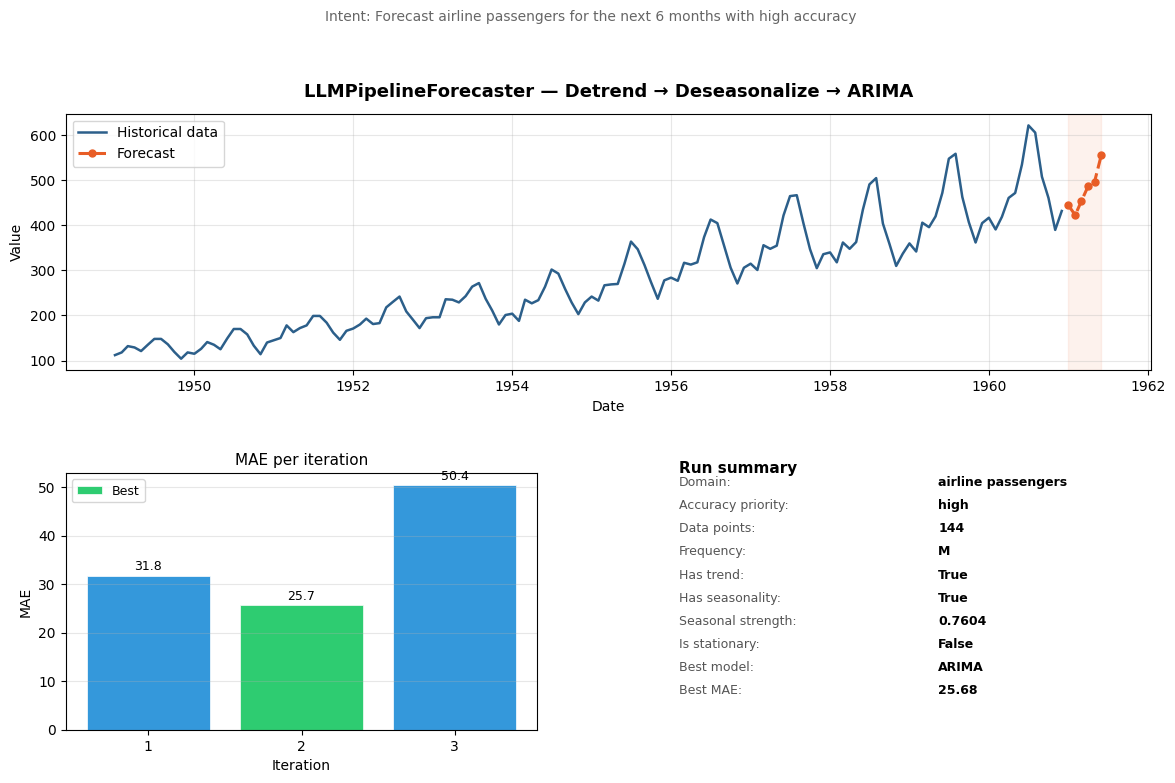

Plot saved as forecast_plot.png


In [28]:
from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3, 4, 5, 6])

plot_forecast(forecaster, y, y_pred)

Extracting intent from prompt...
Intent: {'horizon': 6, 'accuracy_priority': 'high', 'force_model': None, 'ignore_seasonality': False, 'domain': 'airline', 'intent_summary': 'Forecast airline passengers for the next 6 months with high accuracy'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Since previous attempt with ets failed, trying a different model, arima, given the presence of trend and seasonality in the data.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Given previous attempts with ets and arima models, trying a different approach with naive model for airline passengers forecasting.
MAE: 50.40 (relative: 0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


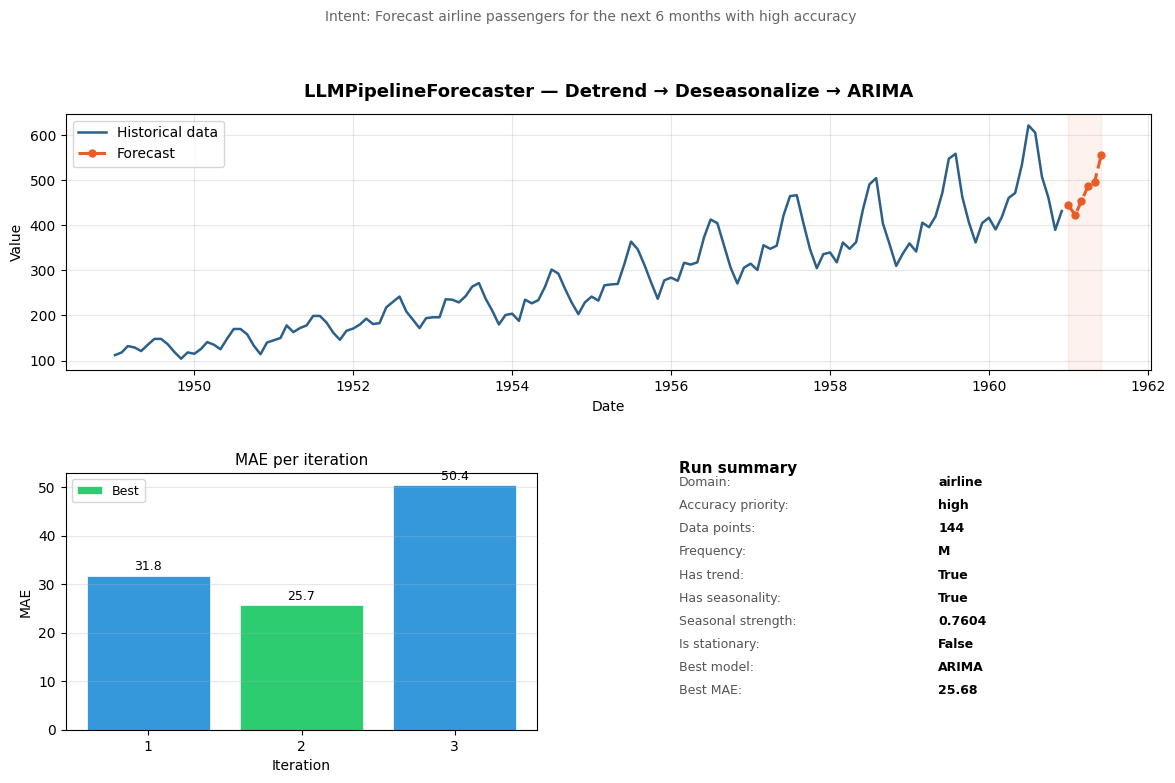

Plot saved as forecast_plot.png


In [29]:
forecaster2 = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
forecaster2.fit(y)
y_pred2 = forecaster2.predict(fh=[1, 2, 3, 4, 5, 6])
plot_forecast(forecaster2, y, y_pred2)

In [30]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.datasets import load_airline

y = load_airline()

# test naive intervals
f = NaiveForecaster(strategy="last")
f.fit(y)
intervals = f.predict_interval(fh=[1,2,3], coverage=0.9)
print("Naive intervals:")
print(intervals)
print()

# test ETS intervals
f2 = ExponentialSmoothing(trend="add", seasonal="add", sp=12)
f2.fit(y)
intervals2 = f2.predict_interval(fh=[1,2,3], coverage=0.9)
print("ETS intervals:")
print(intervals2)

Naive intervals:
        Number of airline passengers            
                                 0.9            
                               lower       upper
1961-01                   376.551313  487.448687
1961-02                   353.583715  510.416285
1961-03                   335.960057  528.039943



NotImplementedError: ExponentialSmoothing does not have the capability to return prediction intervals. If you think this estimator should have the capability, please open an issue on sktime.

In [31]:
from sktime.forecasting.arima import AutoARIMA

f3 = AutoARIMA(sp=12)
f3.fit(y)
intervals3 = f3.predict_interval(fh=[1,2,3], coverage=0.9)
print("ARIMA intervals:")
print(intervals3)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA intervals:
        Number of airline passengers            
                                 0.9            
                               lower       upper
1961-01                   432.560572  470.133581
1961-02                   404.832480  449.371963
1961-03                   438.105029  488.659951


In [39]:
from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3, 4, 5, 6])

print("=== PREDICTION INTERVALS ===")
intervals = forecaster._predict_interval(fh=[1, 2, 3, 4, 5, 6], coverage=0.9)
print(intervals)

print("\n=== CONFIDENCE ASSESSMENT ===")
confidence = forecaster.get_confidence_assessment()
for k, v in confidence.items():
    print(f"{k}: {v}")


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ETS is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Switching to arima model as previous attempt with ets model had a relatively high MAE and the data has both trend and seasonality.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Trying a different model, naive, to improve on previous attempts with ets and arima.
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 25.68
Refitting best pipeline on full data...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== PREDICTION INTERVALS ===
        Number of airline passengers            
                                 0.9            
                               lower       upper
1961-01                   425.922772  462.581782
1961-02                   399.842715  445.961225
1961-03                   428.093245  478.918078
1961-04                   460.033114  513.409163
1961-05                   469.787273  524.595099
1961-06                   528.482441  584.107524

=== CONFIDENCE ASSESSMENT ===
confidence: medium
reasons: ['The model has a fair relative MAE of 0.214, indicating some degree of accuracy but room for improvement', 'The data has both trend and seasonality, which can be challenging to model accurately']



--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ETS is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Switching to arima model as previous attempt with ets model had a relatively high MAE and the data has both trend and seasonality.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Trying a different model, naive, to improve on previous attempts with ets and arima.
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 25.68
Refitting best pipeline on full data...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


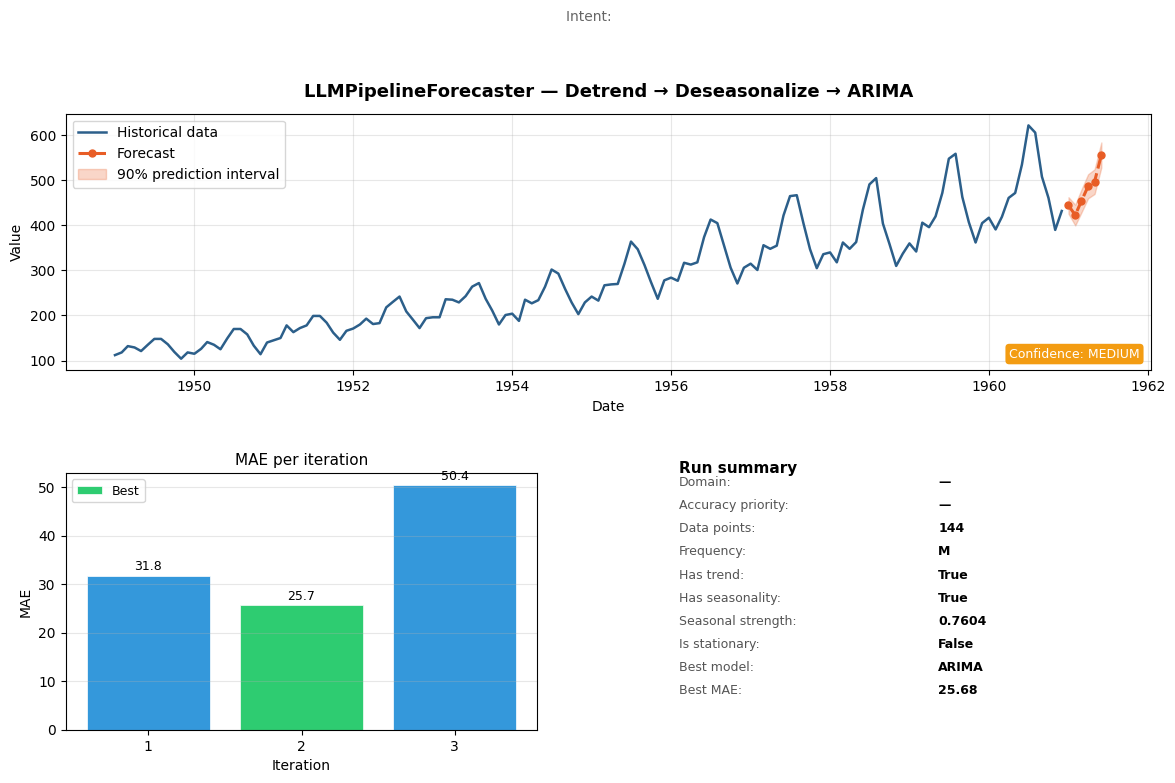

Plot saved as forecast_plot.png


In [40]:
forecaster3 = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)
forecaster3.fit(y)
y_pred3 = forecaster3.predict(fh=[1, 2, 3, 4, 5, 6])
plot_forecast(forecaster3, y, y_pred3)